# 載入函式庫與資料集

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [2]:
np.random.seed(627)  # 指定亂數種子：只要不更改，每次運作時即可保持再現性
# 載入資料集
df = pd.read_csv("./titanic_data.csv")

In [3]:
# 查看前5筆記錄
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,Allen Miss. Elisabeth Walton,female,29.0000,0,0,24160,211.3375,B5,S
1,1,1,Allison Master. Hudson Trevor,male,0.9167,1,2,113781,151.5500,C22 C26,S
2,1,0,Allison Miss. Helen Loraine,female,2.0000,1,2,113781,151.5500,C22 C26,S
3,1,0,Allison Mr. Hudson Joshua Creighton,male,30.0000,1,2,113781,151.5500,C22 C26,S
4,1,0,Allison Mrs. Hudson J C (Bessie Waldo Daniels),female,25.0000,1,2,113781,151.5500,C22 C26,S


鐵達尼號乘客資料集 各欄位說明可參考：
*   https://www.kaggle.com/competitions/titanic/data
*   https://ithelp.ithome.com.tw/articles/10200327


In [4]:
# 顯示資料集的形狀
df.shape

(1309, 11)

In [5]:
# 顯示資料集的描述資料
df.describe()

,pclass,survived,age,sibsp,parch,fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200


In [6]:
# 顯示資料集的資訊
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   name      1309 non-null   str    
 3   sex       1309 non-null   str    
 4   age       1046 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   ticket    1309 non-null   str    
 8   fare      1308 non-null   float64
 9   cabin     295 non-null    str    
 10  embarked  1307 non-null   str    
dtypes: float64(2), int64(4), str(5)
memory usage: 112.6 KB


In [7]:
# 顯示沒有資料的筆數
df.isnull().sum()

pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
dtype: int64

# 資料前處理
> 對於真實世界的資料，前處理十分關鍵，也非常需要花精神

In [8]:
# 刪除不需要的欄位
df = df.drop(["name", "ticket", "cabin"], axis=1)

In [ ]:
df[["age"]].mean()

In [9]:
# 處理遺失資料
df[["age"]] = df[["age"]].fillna(value=df[["age"]].mean())
df[["fare"]] = df[["fare"]].fillna(value=df[["fare"]].mean())

df[["embarked"]] = df[["embarked"]].fillna(value=df["embarked"].value_counts().idxmax())
print(df["embarked"].value_counts())
print(df["embarked"].value_counts().idxmax())

embarked
S    916
C    270
Q    123
Name: count, dtype: int64
S


In [10]:
# 轉換分類資料
df["sex"] = df["sex"].map( {"female": 1, "male": 0} ).astype(int)

In [11]:
# Embarked欄位的One-hot編碼
enbarked_one_hot = pd.get_dummies(df["embarked"], prefix="embarked")
df = df.drop("embarked", axis=1)
df = df.join(enbarked_one_hot)

In [12]:
# 將標籤的 survived 欄位移至最後
df_survived = df.pop("survived")
df["survived"] = df_survived

In [13]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S,survived
0,1,1,29.0000,0,0,211.3375,False,False,True,1
1,1,0,0.9167,1,2,151.5500,False,False,True,1
2,1,1,2.0000,1,2,151.5500,False,False,True,0
3,1,0,30.0000,1,2,151.5500,False,False,True,0
4,1,1,25.0000,1,2,151.5500,False,False,True,0


In [14]:
len(df)

1309

In [15]:
# 分割成訓練(80%)和測試(20%)資料集
mask = np.random.rand(len(df)) < 0.8
df_train = df[mask]
df_test = df[~mask]
print("Train:", df_train.shape)
print("Test:", df_test.shape)
# 儲存處理後的資料
df_train.to_csv("titanic_train.csv", index=False)
df_test.to_csv("titanic_test.csv", index=False)

Train: (1069, 10)
Test: (240, 10)


In [16]:
df

,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S,survived
0,1,1,29.000000,0,0,211.3375,False,False,True,1
1,1,0,0.916700,1,2,151.5500,False,False,True,1
2,1,1,2.000000,1,2,151.5500,False,False,True,0
3,1,0,30.000000,1,2,151.5500,False,False,True,0
4,1,1,25.000000,1,2,151.5500,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...
1304,3,1,14.500000,1,0,14.4542,True,False,False,0
1305,3,1,29.881135,1,0,14.4542,True,False,False,0
1306,3,0,26.500000,0,0,7.2250,True,False,False,0
1307,3,0,27.000000,0,0,7.2250,True,False,False,0


# 載入已經預處理好的資料
> 上述資料集整理處理完，往後即能直接載入資料集，不需每次都要重新處理原始資料

In [17]:
np.random.seed(627)  # 指定亂數種子：只要不更改，每次運作時即可保持再現性
# 載入Titanic的訓練和測試資料集
df_train = pd.read_csv("./titanic_train.csv", dtype='float')
df_test = pd.read_csv("./titanic_test.csv", dtype='float')
dataset_train = df_train.values.copy()
dataset_test = df_test.values.copy()

In [18]:

# 分割成特徵資料和標籤資料
X_train = dataset_train[:, 0:9]
Y_train = dataset_train[:, 9]
X_test = dataset_test[:, 0:9]
Y_test = dataset_test[:, 9]

# 特徵標準化
X_train -= X_train.mean(axis=0)
X_train /= X_train.std(axis=0)
X_test -= X_test.mean(axis=0)
X_test /= X_test.std(axis=0)

# 載入先前訓練過的模型（keras格式）

> 若你有先前訓練並存檔的模型，在此載入。若無，則不需執行此cell



In [ ]:
# 載入模型
from tensorflow.keras.models import load_model

model = Sequential()
model = load_model("413570012_0501.keras") #學號+日期當作主檔名

# 建立模型
> 若已載入先前訓練過的模型，則此處不要執行。

In [19]:
# 定義模型
model = Sequential()
model.add(Dense(40, input_dim=X_train.shape[1], activation="relu"))
model.add(Dense(30, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.summary()   # 顯示模型摘要資訊

/Users/lin/Downloads/mlp-prediction/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,661 (6.49 KB)

 Trainable params: 1,661 (6.49 KB)

 Non-trainable params: 0 (0.00 B)

# 訓練神經網路

In [20]:
# 編譯模型
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [21]:
# 訓練模型
print("Training ...")
history = model.fit(X_train, Y_train, validation_split=0.2, epochs=100, batch_size=32)

Training ...
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6690 - loss: 0.6412 - val_accuracy: 0.8178 - val_loss: 0.5350
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7591 - loss: 0.5455 - val_accuracy: 0.8131 - val_loss: 0.4750
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7906 - loss: 0.4950 - val_accuracy: 0.8131 - val_loss: 0.4396
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8012 - loss: 0.4636 - val_accuracy: 0.8037 - val_loss: 0.4294
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8094 - loss: 0.4470 - val_accuracy: 0.8084 - val_loss: 0.4135
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8164 - loss: 0.4388 - val_accuracy: 0.8084 - val_loss: 0.4094
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8164 - loss: 0.4335 - val_accuracy: 0.8084 - val_loss: 0.4032
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8187 - loss: 0.4289 - val_accurac

In [22]:
# 評估模型
print("\nTesting ...")
loss, accuracy = model.evaluate(X_train, Y_train, verbose=0)
print("訓練資料集的準確度 = {:.2f}".format(accuracy))
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print("測試資料集的準確度 = {:.2f}".format(accuracy))


Testing ...
訓練資料集的準確度 = 0.84
測試資料集的準確度 = 0.76


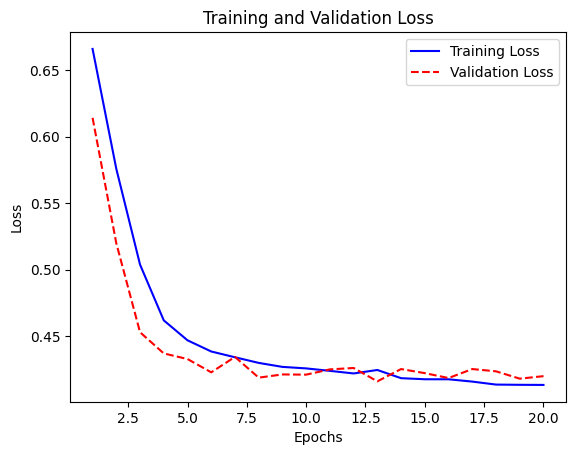

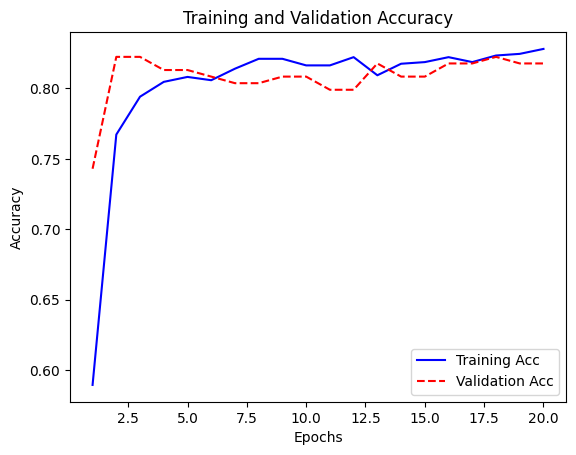

In [30]:
# 顯示圖表來分析模型的訓練過程
import matplotlib.pyplot as plt
# 顯示訓練和驗證損失
loss = history.history["loss"]
epochs = range(1, len(loss)+1)
val_loss = history.history["val_loss"]
plt.plot(epochs, loss, "b-", label="Training Loss")
plt.plot(epochs, val_loss, "r--", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
# 顯示訓練和驗證準確度
acc = history.history["accuracy"]
epochs = range(1, len(acc)+1)
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "b-", label="Training Acc")
plt.plot(epochs, val_acc, "r--", label="Validation Acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 重新執行模型定義與訓練
> 從上述歷程追蹤來觀察適合的迭代次數，避免過度學習造成overfitting

In [24]:
model = Sequential()
model.add(Dense(40, input_dim=X_train.shape[1], activation="relu"))
model.add(Dense(30, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(X_train, Y_train, validation_split=0.2, epochs=20, batch_size=32, verbose=0)  # epochs改為適當的迭代次數

In [25]:
# 評估模型
print("\nTesting ...")
loss, accuracy = model.evaluate(X_train, Y_train, verbose=0)
print("訓練資料集的準確度 = {:.2f}".format(accuracy))
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print("測試資料集的準確度 = {:.2f}".format(accuracy))


Testing ...
訓練資料集的準確度 = 0.83
測試資料集的準確度 = 0.79


In [26]:
# 儲存Keras模型
print("Saving Model ...")
model.save("413570012_0501.keras") #學號+日期當作主檔名

Saving Model ...


In [27]:
# 計算分類的預測值
print("\nPredicting ...")
Y_pred = (model.predict(X_test) > 0.5).astype("int32") # 預測機率轉換成0或1，大於0.5為1、小於等於0.5為0
print(Y_pred.reshape(-1))
print(Y_test.astype(int))


Predicting ...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 1 1 0 0 0
 0 1 0 1 0 1 0 0 0 1 1 0 1 1 1 0 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0
 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 1
 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1
 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0]
[1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 0
 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 1 1 0
 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0
 1 1 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 1 0

In [28]:
# 顯示混淆矩陣
tb = pd.crosstab(Y_test.astype(int), Y_pred.reshape(-1), rownames=["label"], colnames=["predict"])
tb

predict,0,1
label,,
0,126,18
1,33,63


In [29]:
# 作業分數評分公式:(測試資料集準確度-|訓練資料準確度-測試資料準確度|)*100+10

loss, accuracy_train = model.evaluate(X_train, Y_train, verbose=0)
print("訓練資料集的準確度 = {:.2f}".format(accuracy_train))
loss, accuracy_test = model.evaluate(X_test, Y_test, verbose=0)
print("測試資料集的準確度 = {:.2f}".format(accuracy_test))

score = (accuracy_test - np.abs(accuracy_train-accuracy_test))*100 + 10
print("作業分數 = {:.0f}".format(score))

訓練資料集的準確度 = 0.83
測試資料集的準確度 = 0.79
作業分數 = 85


# 加入Jack & Rose資料

In [ ]:
Jack = pd.Series([3, 0, 23, 1, 0,  5.0000,0,0,1,0])
Rose = pd.Series([1, 1, 20, 1, 0, 100.0000,0,0,1,1])

In [ ]:
JR_df = pd.DataFrame([list(Jack),list(Rose)],
            columns=['pclass', 'sex', 'age', 'sibsp','parch', 'fare','embarked_C','embarked_Q','embarked_S','survived'])

In [ ]:
all_df=pd.concat([df_test,JR_df])

In [ ]:
all_df[-2:]

In [ ]:
dataset_test = all_df.values
X_test = dataset_test[:, 0:9]
Y_test = dataset_test[:, 9]
# 特徵標準化
X_test -= X_test.mean(axis=0)
X_test /= X_test.std(axis=0)

In [ ]:
# 計算分類的預測值
print("\nPredicting ...")
all_probability = model.predict(X_test)
Y_pred = (all_probability > 0.5).astype("int32") # 預測機率轉換成0或1，大於0.5為1、小於等於0.5為0

In [ ]:
pd=all_df
pd.insert(len(all_df.columns),'probability',all_probability)

In [ ]:
pd[-2:]